<a href="https://colab.research.google.com/github/Tolureis/CMPE-460-Deep-Learning/blob/main/Shattered_Gradients_with_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Plotting shattered gradients...


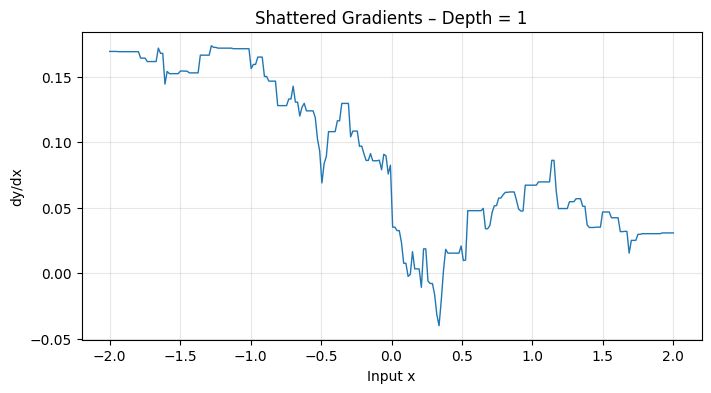

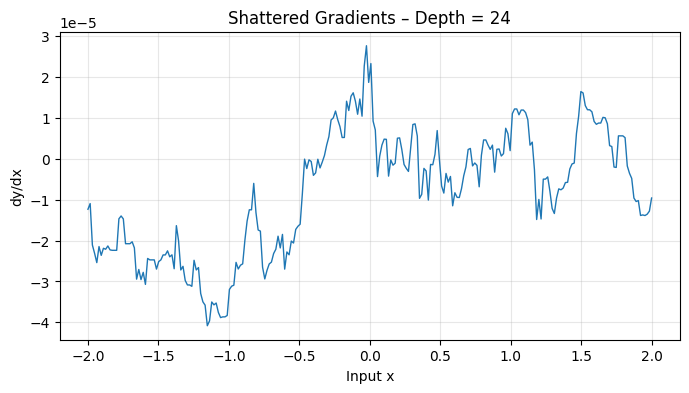

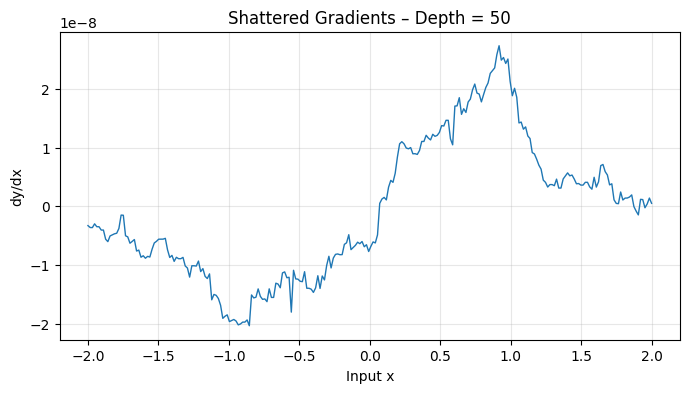

Plotting autocorrelation curves...


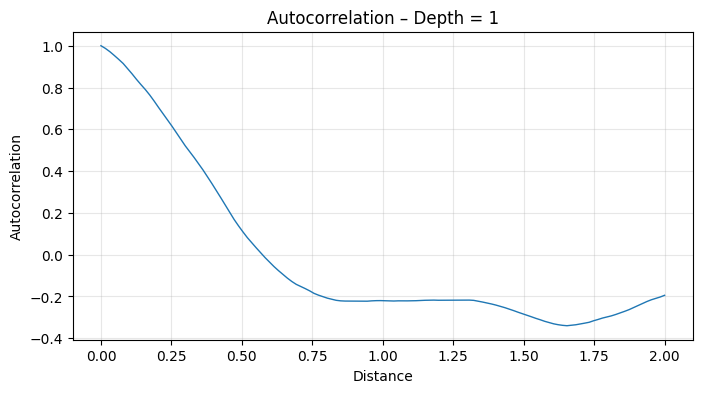

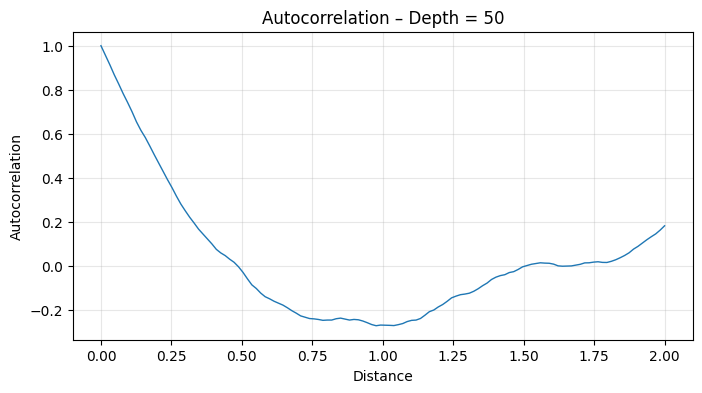

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np


# -----------------------------------------------------------
# 1) Deep ReLU network definition
# -----------------------------------------------------------
class DeepReLU(nn.Module):
    def __init__(self, depth=1, width=200):
        super().__init__()
        layers = []

        # First hidden layer
        layers.append(nn.Linear(1, width))
        layers.append(nn.ReLU())

        # Intermediate hidden layers
        for _ in range(depth - 1):
            layers.append(nn.Linear(width, width))
            layers.append(nn.ReLU())

        # Output layer
        layers.append(nn.Linear(width, 1))

        self.net = nn.Sequential(*layers)

        # Xavier (Glorot) initialization
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.normal_(m.bias, std=np.sqrt(1.0 / width))

    def forward(self, x):
        return self.net(x)


# -----------------------------------------------------------
# 2) Compute gradients dy/dx using autograd
# -----------------------------------------------------------
def compute_gradients(model, x):
    x = x.clone().requires_grad_(True)
    y = model(x)

    # dy/dx via autograd
    dydx = torch.autograd.grad(
        y, x,
        grad_outputs=torch.ones_like(y),
        create_graph=False
    )[0]

    return dydx.detach().cpu().numpy()


# -----------------------------------------------------------
# 3) Plot gradient signal over 1D input range
# -----------------------------------------------------------
def plot_gradients(depth, width=200):
    model = DeepReLU(depth=depth, width=width)

    # Sample 256 points between -2 and 2
    x_vals = torch.linspace(-2, 2, 256).unsqueeze(1)
    dy_vals = compute_gradients(model, x_vals)

    plt.figure(figsize=(8, 4))
    plt.plot(x_vals.detach().numpy(), dy_vals, linewidth=1)
    plt.title(f"Shattered Gradients – Depth = {depth}")
    plt.xlabel("Input x")
    plt.ylabel("dy/dx")
    plt.grid(alpha=0.3)
    plt.show()


# -----------------------------------------------------------
# 4) Autocorrelation function
# -----------------------------------------------------------
def autocorrelation(signal):
    signal = signal - np.mean(signal)
    corr = np.correlate(signal, signal, mode="same")

    # Normalize so that autocorrelation(0) = 1
    corr = corr / corr[len(corr) // 2]
    return corr


# Plot autocorrelation for a model
def plot_autocorr(depth, width=200):
    model = DeepReLU(depth=depth, width=width)
    x_vals = torch.linspace(-2, 2, 256).unsqueeze(1)

    grads = compute_gradients(model, x_vals).flatten()
    ac = autocorrelation(grads)

    half = len(ac) // 2

    plt.figure(figsize=(8, 4))
    plt.plot(np.linspace(0, 2, half), ac[half:], linewidth=1)
    plt.title(f"Autocorrelation – Depth = {depth}")
    plt.xlabel("Distance")
    plt.ylabel("Autocorrelation")
    plt.grid(alpha=0.3)
    plt.show()


# -----------------------------------------------------------
# 5) Run experiments
# -----------------------------------------------------------

print("Plotting shattered gradients...")

plot_gradients(depth=1)     # Shallow network – smooth regions
plot_gradients(depth=24)    # Intermediate depth – gradients become irregular
plot_gradients(depth=50)    # Deep network – shattered gradients

print("Plotting autocorrelation curves...")

plot_autocorr(depth=1)
plot_autocorr(depth=50)
